# EE 446 Homework 1 Programming Notebook

Use the **tinyml-arduino** Python environment that you set up for this class. In JupyterLab, select the kernel named **Python (tinyml-arduino)** before running this notebook.

Do not install or uninstall TensorFlow packages inside this notebook. The class environment already contains the required packages for this assignment, including TensorFlow, TensorFlow Model Optimization Toolkit, scikit-learn, NumPy, pandas, and JupyterLab.

This notebook contains the programming questions marked **[Pro]**. Complete each section by replacing the placeholder comments with your own code. Print the requested outputs so that your work can be graded directly from the notebook.


In [2]:
import sys
print(sys.executable)

/Users/y/ai/projects/tinyml-arduino/bin/python


In [3]:
import sys
!{sys.executable} -m pip install "tensorflow-model-optimization==0.8.0"

In [4]:
import sys
!{sys.executable} -m pip install "keras==2.14.0"

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, r2_score

import tensorflow as tf
import tensorflow_model_optimization as tfmot

Sequential = tf.keras.Sequential
Dense = tf.keras.layers.Dense
LSTM = tf.keras.layers.LSTM
to_categorical = tf.keras.utils.to_categorical

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0



---

# Problem 1: DNN and Wine Classification (80 points)

This problem uses the Wine dataset available through scikit-learn. The dataset is loaded locally from the installed package, so no external data file is required.


In [6]:
# Load the Wine dataset from scikit-learn.
# This avoids requiring an external wine.data file.

wine = load_wine(as_frame=True)
feature_names = list(wine.feature_names)
df = wine.frame.copy()
df["Class"] = wine.target
# Reorder the columns so that the class label appears first.
df = df[["Class"] + feature_names]

# Number of classes
num_classes = df["Class"].nunique()
print("Number of classes:", num_classes)

# Number of features, excluding the class label
num_features = df.shape[1] - 1
print("Number of features:", num_features)

# Basic feature statistics
feature_stats = df.drop(columns=["Class"]).describe().T[["min", "max", "mean", "std"]]
print("\nFeature statistics:\n", feature_stats)

# Class distribution
class_counts = df["Class"].value_counts().sort_index()
print("\nClass distribution:\n", class_counts)


Number of classes: 3
Number of features: 13

Feature statistics:
                                  min      max        mean         std
alcohol                        11.03    14.83   13.000618    0.811827
malic_acid                      0.74     5.80    2.336348    1.117146
ash                             1.36     3.23    2.366517    0.274344
alcalinity_of_ash              10.60    30.00   19.494944    3.339564
magnesium                      70.00   162.00   99.741573   14.282484
total_phenols                   0.98     3.88    2.295112    0.625851
flavanoids                      0.34     5.08    2.029270    0.998859
nonflavanoid_phenols            0.13     0.66    0.361854    0.124453
proanthocyanins                 0.41     3.58    1.590899    0.572359
color_intensity                 1.28    13.00    5.058090    2.318286
hue                             0.48     1.71    0.957449    0.228572
od280/od315_of_diluted_wines    1.27     4.00    2.611685    0.709990
proline                 

## Problem 1 - Part (a)
### Base Model Training and Evaluation


In [9]:
# Step 1: Separate the feature matrix and class labels.
# - Assign the feature columns to variable X.
# - Assign the class labels to variable y.
# - The labels in this scikit-learn dataset are already zero-based: 0, 1, and 2.

# <-- Enter your code here <--#
X = df.drop(columns=['Class']).values
y = df['Class'].values


In [10]:
# Step 2: Perform a train-test split (70% train, 30% test) using random_state=42

# <-- Enter your code here <--#
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test → ~142 / 36 samples
    random_state=42,    # reproducibility
    stratify=y          # preserve class balance
)


In [21]:
# Step 3: Use StandardScaler to normalize the features
# - Fit on X_train and transform both X_train and X_test

# <-- Enter your code here <--
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


In [22]:
# Step 4: Use one-hot encoding for y_train and y_test.
# - Use tf.keras.utils.to_categorical.
# - Use num_classes=num_classes to make the output shape explicit.

# <-- Enter your code here <--#
y_train_ohe = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_ohe  = tf.keras.utils.to_categorical(y_test,  num_classes=num_classes)


In [23]:
# Step 5: Define a Sequential model with the following architecture:
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(num_classes, activation='softmax')
# Make sure the first Dense layer receives the correct input shape.

# <-- Enter your code here <--#
model = Sequential([
    Dense(64, activation='relu', input_shape=(num_features,)),  # num_features=13
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')                    # num_classes=3
])

model.summary()   # prints layer shapes and parameter counts — always check this!



Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                896       
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 3)                 99        
                                                                 
Total params: 3075 (12.01 KB)
Trainable params: 3075 (12.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [24]:
# Step 6: Compile using Adam optimizer, categorical_crossentropy loss, and accuracy metric
# - Train for 20 epochs with batch_size=8 and validation_split=0.2

# <-- Enter your code here <--#
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled, y_train_ohe,
    epochs=20,
    batch_size=8,           # small batch → noisier but often better generalisation
    validation_split=0.2,   # uses last 20% of train rows as validation
    verbose=1
)


Epoch 1/20
15/15 [==============================] - 0s 5ms/step - loss: 0.9936 - accuracy: 0.5929 - val_loss: 0.9120 - val_accuracy: 0.5517
Epoch 2/20
15/15 [==============================] - 0s 1ms/step - loss: 0.6214 - accuracy: 0.7965 - val_loss: 0.5969 - val_accuracy: 0.8276
Epoch 3/20
15/15 [==============================] - 0s 1ms/step - loss: 0.3977 - accuracy: 0.9381 - val_loss: 0.4052 - val_accuracy: 0.9655
Epoch 4/20
15/15 [==============================] - 0s 1ms/step - loss: 0.2740 - accuracy: 0.9823 - val_loss: 0.2703 - val_accuracy: 1.0000
Epoch 5/20
15/15 [==============================] - 0s 1ms/step - loss: 0.1939 - accuracy: 0.9823 - val_loss: 0.1865 - val_accuracy: 1.0000
Epoch 6/20
15/15 [==============================] - 0s 1ms/step - loss: 0.1419 - accuracy: 0.9823 - val_loss: 0.1358 - val_accuracy: 1.0000
Epoch 7/20
15/15 [==============================] - 0s 1ms/step - loss: 0.1082 - accuracy: 0.9912 - val_loss: 0.1026 - val_accuracy: 1.0000
Epoch 8/20
15/15 [==


Test loss    : 0.1346
Test accuracy: 0.9444
2/2 [==============================] - 0s 944us/step

─── Neural Net Classification Report ───────────────────────────
              precision    recall  f1-score   support

     Class 0       1.00      0.92      0.96        12
     Class 1       0.88      1.00      0.93        14
     Class 2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



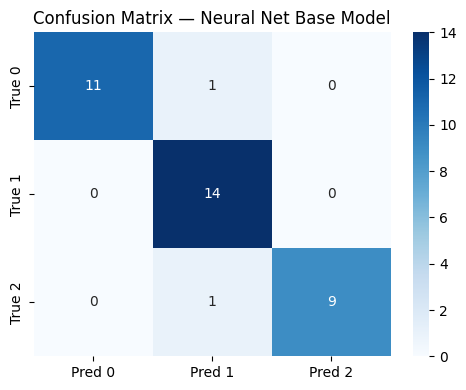

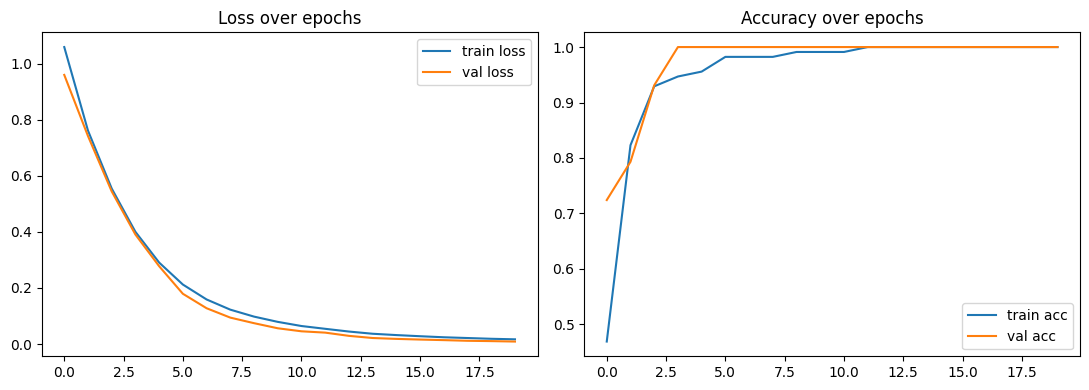

In [19]:
# Step 7: Evaluate the model on test data and print:
# - Accuracy
# - Classification report
# - Confusion matrix

# <-- Enter your code here <--#
import seaborn as sns
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_ohe, verbose=0)
print(f"\nTest loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# --- 7b: Classification report ---
# model.predict() returns a (36, 3) probability matrix.
# np.argmax(..., axis=1) picks the column with the highest probability
# → converts back to integer class labels so sklearn can read them.
y_pred_probs = model.predict(X_test_scaled)
y_pred       = np.argmax(y_pred_probs, axis=1)   # e.g. [0.1, 0.7, 0.2] → 1

print("\n─── Neural Net Classification Report ───────────────────────────")
print(classification_report(y_test, y_pred,
                             target_names=["Class 0", "Class 1", "Class 2"]))

# --- 7c: Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0","Pred 1","Pred 2"],
            yticklabels=["True 0","True 1","True 2"])
ax.set_title("Confusion Matrix — Neural Net Base Model")
plt.tight_layout()
plt.show()

# --- 7d: Training curves (bonus — always plot these) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history.history['loss'],     label='train loss')
ax1.plot(history.history['val_loss'], label='val loss')
ax1.set_title('Loss over epochs'); ax1.legend()

ax2.plot(history.history['accuracy'],     label='train acc')
ax2.plot(history.history['val_accuracy'], label='val acc')
ax2.set_title('Accuracy over epochs'); ax2.legend()
plt.tight_layout()
plt.show()


In [20]:
# Step 8: Convert the trained model to TFLite format and save it as "model_base.tflite"
# - Print the file size in kilobytes

# <-- Enter your code here <--#
converter   = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_path = "model_base.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

file_size_kb = len(tflite_model) / 1024
print(f"\nTFLite model saved → '{tflite_path}'")
print(f"File size: {file_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp885t7rht/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp885t7rht/assets



TFLite model saved → 'model_base.tflite'
File size: 14.07 KB


2026-05-18 22:04:47.716528: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-18 22:04:47.716547: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-18 22:04:47.716859: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp885t7rht
2026-05-18 22:04:47.717315: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-18 22:04:47.717319: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp885t7rht
2026-05-18 22:04:47.718747: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-05-18 22:04:47.719140: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-18 22:04:47.741329: I tensorflow/cc/saved_model/loader.

## Problem 1 - Part (b)

### Quantization (int8, float16, dynamic range)


In [28]:
import os

def file_size_kb(filename):
    """Return file size in kilobytes."""
    return os.path.getsize(filename) / 1024

INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp2hfc0ut9/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp2hfc0ut9/assets



DYNAMIC TFLite model size: 8.20 KB

───────────────────────────────────────────────────────
  DYNAMIC Quantized TFLite Model
───────────────────────────────────────────────────────
  File : model_dynamic.tflite
  Size : 8.20 KB

              precision    recall  f1-score   support

     Class 0       1.00      0.92      0.96        12
     Class 1       0.88      1.00      0.93        14
     Class 2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



2026-05-19 09:07:21.942328: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 09:07:21.942343: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 09:07:21.942439: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp2hfc0ut9
2026-05-19 09:07:21.942894: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 09:07:21.942899: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp2hfc0ut9
2026-05-19 09:07:21.944128: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 09:07:21.963169: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp2hfc0ut9
2026-05-

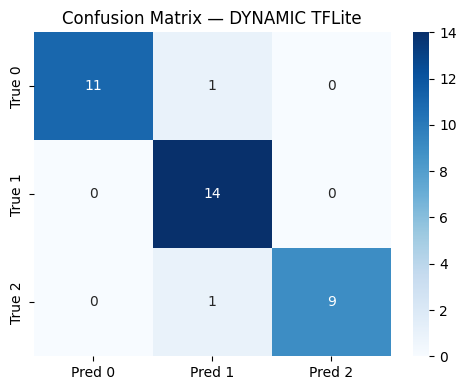

INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmppnmux00n/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmppnmux00n/assets



FLOAT16 TFLite model size: 9.00 KB

───────────────────────────────────────────────────────
  FLOAT16 Quantized TFLite Model
───────────────────────────────────────────────────────
  File : model_float16.tflite
  Size : 9.00 KB

              precision    recall  f1-score   support

     Class 0       1.00      0.92      0.96        12
     Class 1       0.88      1.00      0.93        14
     Class 2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



2026-05-19 09:07:22.276977: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 09:07:22.276993: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 09:07:22.277101: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmppnmux00n
2026-05-19 09:07:22.277619: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 09:07:22.277623: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmppnmux00n
2026-05-19 09:07:22.278861: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 09:07:22.298672: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmppnmux00n
2026-05-

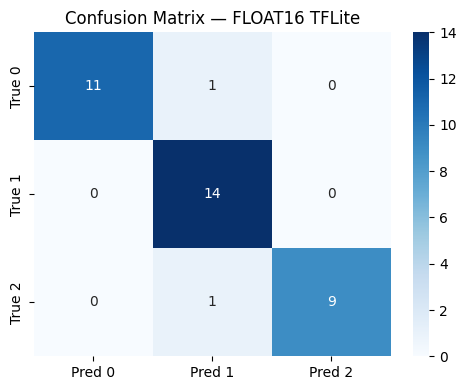

INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpi_q90mm0/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpi_q90mm0/assets



INT8 TFLite model size: 5.76 KB

───────────────────────────────────────────────────────
  INT8 Quantized TFLite Model
───────────────────────────────────────────────────────
  File : model_int8.tflite
  Size : 5.76 KB

              precision    recall  f1-score   support

     Class 0       1.00      0.92      0.96        12
     Class 1       0.88      1.00      0.93        14
     Class 2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



/Users/y/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-19 09:07:22.817027: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 09:07:22.817041: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 09:07:22.817131: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpi_q90mm0
2026-05-19 09:07:22.817540: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 09:07:22.817545: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpi_q90mm0
2026-05-19 09:07:22.818655: I tensorflow/cc/saved_model/loader.cc:233] Restor

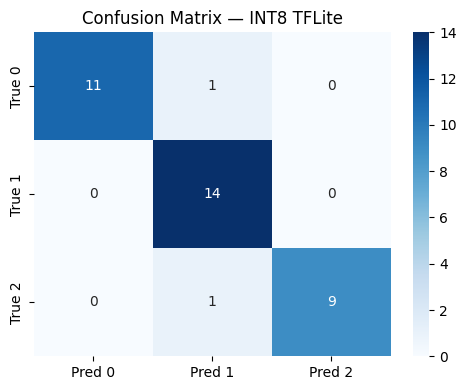

In [33]:
def representative_data_gen(X_reference, num_samples=100):
    """Create a representative dataset generator for full integer quantization."""
    max_samples = min(num_samples, len(X_reference))
    for i in range(max_samples):
        yield [X_reference[i:i + 1].astype(np.float32)]


def quantize_and_evaluate(model, X_test, y_test_cat, quant_type, filename):
    """Convert a Keras model to TFLite, evaluate it, and report model size.

    Parameters
    ----------
    model : tf.keras.Model
        Trained Keras model.
    X_test : np.ndarray
        Test features after the same preprocessing used for training.
    y_test_cat : np.ndarray
        One-hot encoded test labels.
    quant_type : str
        One of: 'int8', 'float16', or 'dynamic'.
    filename : str
        Output TFLite filename.
    """

    # Create the TFLite converter from the trained Keras model.
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Step 1: Apply quantization settings.
    if quant_type == 'int8':
        # (a) Enable default optimizations.
        # (b) Provide representative_data_gen(X_train_scaled).
        # (c) Set supported_ops to TFLITE_BUILTINS_INT8.
        # (d) Set inference_input_type and inference_output_type to tf.int8.

        # <-- Enter your code here <--#
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = lambda: representative_data_gen(X_train_scaled)
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

        converter.inference_input_type  = tf.int8
        converter.inference_output_type = tf.int8
        
    elif quant_type == 'float16':
        # (a) Enable default optimizations.
        # (b) Set supported_types to [tf.float16].

        # <-- Enter your code here <--#
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]

    elif quant_type == 'dynamic':
        # (a) Enable default optimizations.

        # <-- Enter your code here <--#
        converter.optimizations = [tf.lite.Optimize.DEFAULT]


    else:
        raise ValueError("quant_type must be one of: 'int8', 'float16', or 'dynamic'.")

    # Step 2: Convert the model and save it to the provided filename.

    # <-- Enter your code here <--#
    tflite_model = converter.convert()

    with open(filename, "wb") as f:
        f.write(tflite_model)

    # Step 3: Run TFLite inference.
    # Complete the following:
    # - Use tf.lite.Interpreter to load the TFLite model.
    # - Allocate tensors.
    # - Get input and output tensor details.
    # - If the input is quantized, quantize each test sample using scale and zero point.
    # - If the output is quantized, dequantize the prediction using scale and zero point.
    # - Collect predictions into y_pred using np.argmax.
    # - Compare with y_true = np.argmax(y_test_cat, axis=1).

    # <-- Enter your code here for TFLite inference <--#
    interpreter = tf.lite.Interpreter(model_path=filename)
    interpreter.allocate_tensors()   # reserves memory for all tensors

    input_details  = interpreter.get_input_details()   # list of dicts per input tensor
    output_details = interpreter.get_output_details()  # list of dicts per output tensor
    
    input_scale,  input_zero_point  = input_details[0]['quantization']   # (s, zp)
    output_scale, output_zero_point = output_details[0]['quantization']

    y_true = np.argmax(y_test_cat, axis=1)
    y_pred = []
    for i in range(len(X_test)):
        sample = X_test[i:i+1].astype(np.float32)   # shape: (1, 13)

        # ── Quantize input if the model expects int8 ──────────────────────────
        # input_scale == 0 means the tensor is NOT quantized (float16 / dynamic).
        # Only int8 models have a non-zero scale.
        if input_scale != 0:
            # float32 → int8:  round( x / scale + zero_point ), clipped to [-128, 127]
            sample = np.round(sample / input_scale + input_zero_point)
            sample = np.clip(sample, -128, 127).astype(np.int8)

        interpreter.set_tensor(input_details[0]['index'], sample)
        interpreter.invoke()   # runs one forward pass

        output = interpreter.get_tensor(output_details[0]['index'])  # shape: (1, 3)

        # ── Dequantize output if the model returns int8 ───────────────────────
        if output_scale != 0:
            # int8 → float32:  (value - zero_point) * scale
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        # argmax over the 3 class scores → predicted class integer
        y_pred.append(np.argmax(output))

    y_pred = np.array(y_pred)

    # Step 4: Report results.
    print(f"\n{quant_type.upper()} TFLite model size: {file_size_kb(filename):.2f} KB")

    # <-- Enter your code here: print classification_report and confusion_matrix <--#
    print(f"\n{'─'*55}")
    print(f"  {quant_type.upper()} Quantized TFLite Model")
    print(f"{'─'*55}")
    print(f"  File : {filename}")
    print(f"  Size : {file_size_kb(filename):.2f} KB")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Class 0','Class 1','Class 2'])}")

    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0","Pred 1","Pred 2"],
                yticklabels=["True 0","True 1","True 2"])
    ax.set_title(f"Confusion Matrix — {quant_type.upper()} TFLite")
    plt.tight_layout()
    plt.show()


# ── Run all three variants ────────────────────────────────────────────────────
quantize_and_evaluate(model, X_test_scaled, y_test_ohe, 'dynamic', 'model_dynamic.tflite')
quantize_and_evaluate(model, X_test_scaled, y_test_ohe, 'float16', 'model_float16.tflite')
quantize_and_evaluate(model, X_test_scaled, y_test_ohe, 'int8',    'model_int8.tflite')



## Problem 1 - Part (c)

### Pruning

In [34]:
# Step 1: Define a pruning schedule using tfmot.sparsity.keras.PolynomialDecay
# HINT:
# - Use initial_sparsity = 0.5 and final_sparsity = 0.7
# - Set end_step to total training steps (approx. dataset_size / batch_size * epochs)

# <-- Enter your code here <--#
dataset_size = len(X_train_scaled)
initial_sparsity = 0.50   # start pruning at 50% zeros
final_sparsity   = 0.70   # finish at 70% zeros

pruning_epochs   = 10
batch_size       = 8
steps_per_epoch = np.ceil(dataset_size / batch_size).astype(int)
end_step        = steps_per_epoch * pruning_epochs

pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity = initial_sparsity,
    final_sparsity   = final_sparsity,
    begin_step       = 0,
    end_step         = end_step,
)


In [35]:
# Step 2: Build a Sequential model with 3 pruned Dense layers:
# - Dense(64, relu)
# - Dense(32, relu)
# - Dense(3, softmax)
# Make sure each Dense layer is wrapped with prune_low_magnitude()

# <-- Enter your code here <--#
prune_layer = tfmot.sparsity.keras.prune_low_magnitude  # alias for readability

model_pruned = Sequential([
    prune_layer(
        Dense(64, activation='relu', input_shape=(num_features,)),
        pruning_schedule=pruning_schedule
    ),
    prune_layer(
        Dense(32, activation='relu'),
        pruning_schedule=pruning_schedule
    ),
    prune_layer(
        Dense(num_classes, activation='softmax'),
        pruning_schedule=pruning_schedule
    )
])

model_pruned.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_dense_  (None, 64)                1730      
 6 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 32)                4130      
 7 (PruneLowMagnitude)                                           
                                                                 
 prune_low_magnitude_dense_  (None, 3)                 197       
 8 (PruneLowMagnitude)                                           
                                                                 
Total params: 6057 (23.67 KB)
Trainable params: 3075 (12.01 KB)
Non-trainable params: 2982 (11.66 KB)
_________________________________________________________________


In [36]:
# Step 3: Compile the model with categorical_crossentropy and accuracy
# - Train for 10 epochs with batch_size=8 and validation_split=0.2
# - Add tfmot.sparsity.keras.UpdatePruningStep() to the callbacks list

# <-- Enter your code here <--#

model_pruned.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep(),  
]

history_pruned = model_pruned.fit(
    X_train_scaled, y_train_ohe,
    epochs=pruning_epochs,          # 10 epochs
    batch_size=batch_size,          # 8
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)



Epoch 1/10
15/15 [==============================] - 1s 6ms/step - loss: 1.1406 - accuracy: 0.3805 - val_loss: 0.8318 - val_accuracy: 0.8621
Epoch 2/10
15/15 [==============================] - 0s 1ms/step - loss: 0.7682 - accuracy: 0.8053 - val_loss: 0.5618 - val_accuracy: 1.0000
Epoch 3/10
15/15 [==============================] - 0s 2ms/step - loss: 0.5218 - accuracy: 0.9381 - val_loss: 0.3795 - val_accuracy: 1.0000
Epoch 4/10
15/15 [==============================] - 0s 1ms/step - loss: 0.3492 - accuracy: 0.9469 - val_loss: 0.2587 - val_accuracy: 1.0000
Epoch 5/10
15/15 [==============================] - 0s 2ms/step - loss: 0.2387 - accuracy: 0.9735 - val_loss: 0.1807 - val_accuracy: 1.0000
Epoch 6/10
15/15 [==============================] - 0s 1ms/step - loss: 0.1710 - accuracy: 0.9735 - val_loss: 0.1235 - val_accuracy: 1.0000
Epoch 7/10
15/15 [==============================] - 0s 2ms/step - loss: 0.2046 - accuracy: 0.9823 - val_loss: 0.2830 - val_accuracy: 1.0000
Epoch 8/10
15/15 [==

In [37]:
# Step 4: Remove pruning wrappers using tfmot.sparsity.keras.strip_pruning().
# Then convert the stripped model to TFLite and save it as "model_pruned.tflite".
# Print the final file size in KB.

# Important: converting the unstripped pruned model can keep extra pruning variables
# and make the saved model larger than expected.

# <-- Enter your code here <--#
model_stripped = tfmot.sparsity.keras.strip_pruning(model_pruned)

# Verify stripping worked — summary should look identical to the base model
model_stripped.summary()
converter = tf.lite.TFLiteConverter.from_keras_model(model_stripped)
tflite_pruned = converter.convert()

pruned_filename = "model_pruned.tflite"
with open(pruned_filename, "wb") as f:
    f.write(tflite_pruned)

print(f"\nPruned TFLite model saved → '{pruned_filename}'")
print(f"File size: {file_size_kb(pruned_filename):.2f} KB")


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 64)                896       
                                                                 
 dense_7 (Dense)             (None, 32)                2080      
                                                                 
 dense_8 (Dense)             (None, 3)                 99        
                                                                 
Total params: 3075 (12.01 KB)
Trainable params: 3075 (12.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpy9awr0l1/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpy9awr0l1/assets



Pruned TFLite model saved → 'model_pruned.tflite'
File size: 14.14 KB


2026-05-19 09:21:16.147042: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 09:21:16.147063: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 09:21:16.147158: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpy9awr0l1
2026-05-19 09:21:16.147498: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 09:21:16.147503: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpy9awr0l1
2026-05-19 09:21:16.148263: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 09:21:16.155986: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpy9awr0l1
2026-05-

2/2 [==============================] - 0s 2ms/step

─── Pruned Model Evaluation ─────────────────────────────────────────
              precision    recall  f1-score   support

     Class 0       1.00      0.92      0.96        12
     Class 1       0.93      1.00      0.97        14
     Class 2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



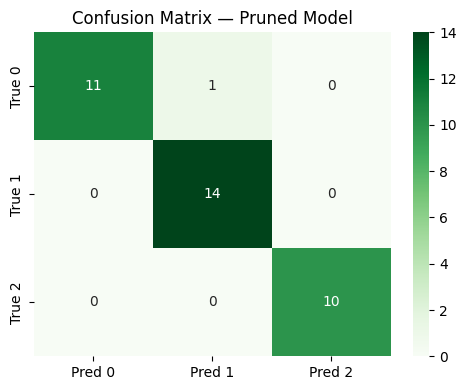

In [38]:
# Step 5: Evaluate using the stripped model
# - Use np.argmax for predictions
# - Print classification_report and confusion_matrix

# <-- Enter your code here <--#
y_pred_probs = model_stripped.predict(X_test_scaled)


y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_ohe,   axis=1)

print("\n─── Pruned Model Evaluation ─────────────────────────────────────────")
print(classification_report(y_true, y_pred,
                             target_names=["Class 0", "Class 1", "Class 2"]))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred 0", "Pred 1", "Pred 2"],
            yticklabels=["True 0", "True 1", "True 2"])
ax.set_title("Confusion Matrix — Pruned Model")
plt.tight_layout()
plt.show()

## Problem 1 - Part (d)

### Knowledge Distillation

In [42]:
# Step 1: Define a Sequential model for Student with:
# - Dense(32, relu)
# - Dense(16, relu)
# - Dense(3, softmax)

# <-- Enter your code here <--#
student_model = Sequential([
    Dense(32, activation='relu', input_shape=(num_features,)),  # num_features=13
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')                    # num_classes=3
])

model.summary()   # prints layer shapes and parameter counts — always check this!



Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 32)                448       
                                                                 
 dense_10 (Dense)            (None, 16)                528       
                                                                 
 dense_11 (Dense)            (None, 3)                 51        
                                                                 
Total params: 1027 (4.01 KB)
Trainable params: 1027 (4.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [40]:
# Step 2: Use model.predict() on X_train_scaled to obtain teacher soft labels

# <-- Enter your code here <--#
teacher_preds_soft = model.predict(X_train_scaled) 

5/5 [==============================] - 0s 743us/step


In [41]:
# Step 3:
# (a) Concatenate hard (y_train_cat) and soft (teacher_preds_soft) labels along axis=1
#     to create a combined label for distillation
# (b) Define a custom distillation_loss() function that:
#     - Splits y_true_combined into y_true_hard and y_true_soft
#     - Computes two losses (both using categorical_crossentropy)
#     - Combines them with a weight factor alpha = 0.5

# Hint: Use slicing [:, :3] and [:, 3:] to split the combined labels

# <-- Enter your code here <--#
y_true_combined = np.concatenate([y_train_ohe, teacher_preds_soft], axis=1)

def distillation_loss(y_true_combined, y_pred):

    # <-- Enter your code here: implement hard/soft label separation and weighted loss <--#
    y_true_hard = y_true_combined[:, :3]   # ground-truth one-hot
    y_true_soft = y_true_combined[:, 3:]   # teacher soft probs
    alpha = 0.5
    hard_loss = tf.keras.losses.categorical_crossentropy(y_true_hard, y_pred)
    soft_loss = tf.keras.losses.categorical_crossentropy(y_true_soft, y_pred)
    
    return alpha * hard_loss + (1 - alpha) * soft_loss


Epoch 1/10
15/15 [==============================] - 0s 6ms/step - loss: 1.0800 - accuracy: 0.2566 - val_loss: 1.0232 - val_accuracy: 0.5862
Epoch 2/10
15/15 [==============================] - 0s 1ms/step - loss: 0.9792 - accuracy: 0.5841 - val_loss: 0.9656 - val_accuracy: 0.7241
Epoch 3/10
15/15 [==============================] - 0s 1ms/step - loss: 0.9229 - accuracy: 0.7965 - val_loss: 0.9296 - val_accuracy: 0.8276
Epoch 4/10
15/15 [==============================] - 0s 1ms/step - loss: 0.8843 - accuracy: 0.9115 - val_loss: 0.9076 - val_accuracy: 0.9310
Epoch 5/10
15/15 [==============================] - 0s 1ms/step - loss: 0.8594 - accuracy: 0.9381 - val_loss: 0.8923 - val_accuracy: 0.9310
Epoch 6/10
15/15 [==============================] - 0s 1ms/step - loss: 0.8437 - accuracy: 0.9646 - val_loss: 0.8821 - val_accuracy: 0.9655
Epoch 7/10
15/15 [==============================] - 0s 1ms/step - loss: 0.8340 - accuracy: 0.9646 - val_loss: 0.8764 - val_accuracy: 0.9655
Epoch 8/10
15/15 [==

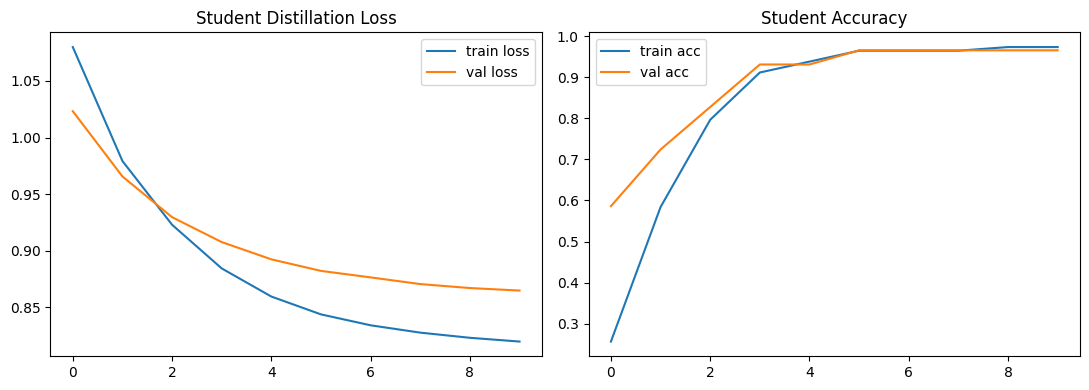

In [45]:
# Step 4: Compile the student model with Adam optimizer and distillation_loss
# - Train for 10 epochs, batch_size=8, validation_split=0.2

# <-- Enter your code here <--#
student_model.compile(
    optimizer='adam',
    loss=distillation_loss,
    metrics=['accuracy']
)
history_kd = student_model.fit(
    X_train_scaled, y_true_combined,   
    epochs=10,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history_kd.history['loss'],     label='train loss')
ax1.plot(history_kd.history['val_loss'], label='val loss')
ax1.set_title('Student Distillation Loss'); ax1.legend()

ax2.plot(history_kd.history['accuracy'],     label='train acc')
ax2.plot(history_kd.history['val_accuracy'], label='val acc')
ax2.set_title('Student Accuracy'); ax2.legend()
plt.tight_layout(); plt.show()




In [46]:
# Step 5: Convert the student model to TFLite.
# - Save it as "model_kd.tflite".
# - Print the file size in KB.

# <-- Enter your code here <--#
converter_kd   = tf.lite.TFLiteConverter.from_keras_model(student_model)
tflite_kd      = converter_kd.convert()

kd_filename = "model_kd.tflite"
with open(kd_filename, "wb") as f:
    f.write(tflite_kd)

print(f"\nKD student TFLite saved → '{kd_filename}'")
print(f"File size: {file_size_kb(kd_filename):.2f} KB")

INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp4avn6q0t/assets


INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp4avn6q0t/assets



KD student TFLite saved → 'model_kd.tflite'
File size: 6.14 KB


2026-05-19 10:27:09.127066: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 10:27:09.127094: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 10:27:09.127199: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp4avn6q0t
2026-05-19 10:27:09.127695: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 10:27:09.127700: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp4avn6q0t
2026-05-19 10:27:09.129002: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-19 10:27:09.148696: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmp4avn6q0t
2026-05-

2/2 [==============================] - 0s 1ms/step

─── Knowledge Distillation Student Evaluation ───────────────────────
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        12
     Class 1       0.88      1.00      0.93        14
     Class 2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



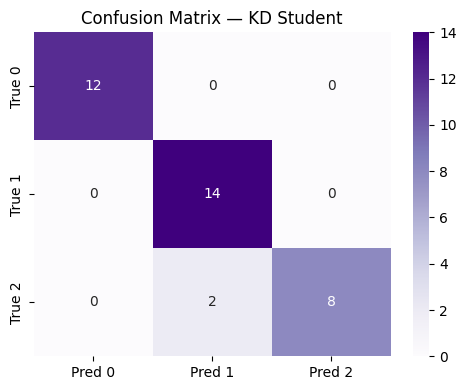

In [47]:
# Step 6: Use student_model.predict() to obtain predictions on X_test_scaled
# - Print classification_report and confusion_matrix

# <-- Enter your code here <--#
y_pred_kd = np.argmax(student_model.predict(X_test_scaled), axis=1)
y_true_test = np.argmax(y_test_ohe, axis=1)

print("\n─── Knowledge Distillation Student Evaluation ───────────────────────")
print(classification_report(y_true_test, y_pred_kd,
                             target_names=["Class 0", "Class 1", "Class 2"]))

cm_kd = confusion_matrix(y_true_test, y_pred_kd)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_kd, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Pred 0", "Pred 1", "Pred 2"],
            yticklabels=["True 0", "True 1", "True 2"])
ax.set_title("Confusion Matrix — KD Student")
plt.tight_layout(); plt.show()

## Problem 1 - Part (e)

### Possibility of Further Model Size Reduction

Can you **further reduce the model size** beyond the smallest model obtained in parts **(b)**, **(c)**, or **(d)**, **without sacrificing significant classification performance**?

Your task is to:

1. **Analyze and compare** the results from previous parts: Which model had the smallest size? Which performed best?

2. **Propose a strategy** that combines or enhances techniques learned so far.

3. **Implement** your proposed solution.

4. **Evaluate** the resulting model using both:
   - TFLite model size (in KB)
   - Classification performance (accuracy and report)

5. **Justify your results:**
   - If further size reduction is **not** possible without major loss of accuracy, explain why.
   - If you succeed in reducing the size **further**, highlight what change made the biggest difference.


### **Note:** If this part includes any code, please include it below. The related discussion should be submitted as part of your PDF that contains answers to all [Dis] questions in this assignment.


Epoch 1/15
15/15 [==============================] - 1s 6ms/step - loss: 1.1209 - accuracy: 0.3274 - val_loss: 1.0582 - val_accuracy: 0.5517
Epoch 2/15
15/15 [==============================] - 0s 1ms/step - loss: 1.0261 - accuracy: 0.6549 - val_loss: 1.0041 - val_accuracy: 0.7241
Epoch 3/15
15/15 [==============================] - 0s 2ms/step - loss: 0.9621 - accuracy: 0.8407 - val_loss: 0.9628 - val_accuracy: 0.7586
Epoch 4/15
15/15 [==============================] - 0s 2ms/step - loss: 0.9129 - accuracy: 0.9204 - val_loss: 0.9315 - val_accuracy: 0.8276
Epoch 5/15
15/15 [==============================] - 0s 2ms/step - loss: 0.8734 - accuracy: 0.9381 - val_loss: 0.9075 - val_accuracy: 0.9310
Epoch 6/15
15/15 [==============================] - 0s 1ms/step - loss: 0.8477 - accuracy: 0.9646 - val_loss: 0.8914 - val_accuracy: 0.9655
Epoch 7/15
15/15 [==============================] - 0s 1ms/step - loss: 0.8527 - accuracy: 0.8938 - val_loss: 0.9901 - val_accuracy: 0.4828
Epoch 8/15
15/15 [==

INFO:tensorflow:Assets written to: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpenzkcncj/assets



Final model saved → 'model_final.tflite'
File size: 3.71 KB

─── Final Model (KD + Pruning + INT8) ──────────────────────
              precision    recall  f1-score   support

     Class 0       0.92      1.00      0.96        12
     Class 1       0.87      0.93      0.90        14
     Class 2       1.00      0.80      0.89        10

    accuracy                           0.92        36
   macro avg       0.93      0.91      0.92        36
weighted avg       0.92      0.92      0.92        36



/Users/y/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-19 10:36:55.558252: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-19 10:36:55.558263: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-19 10:36:55.558352: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpenzkcncj
2026-05-19 10:36:55.558645: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-19 10:36:55.558649: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/v_/3b54zs4d6bbf222t0xyybss00000gn/T/tmpenzkcncj
2026-05-19 10:36:55.559370: I tensorflow/cc/saved_model/loader.cc:233] Restor

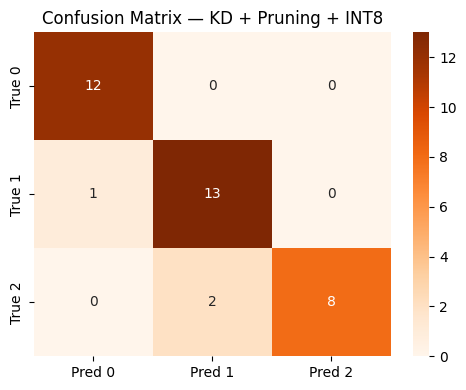

In [49]:
# <-- (if needed) Enter your code here <--#
pruning_epochs_final = 15        # slightly more epochs — model is smaller, needs more time
batch_size_final     = 8

steps_per_epoch_final = np.ceil(len(X_train_scaled) / batch_size_final).astype(int)
end_step_final        = steps_per_epoch_final * pruning_epochs_final

pruning_schedule_final = tfmot.sparsity.keras.PolynomialDecay(
    initial_sparsity = 0.40,
    final_sparsity   = 0.65,
    begin_step       = 0,
    end_step         = end_step_final,
)

prune_layer = tfmot.sparsity.keras.prune_low_magnitude

# Build the same KD student architecture but wrapped with pruning
student_pruned = Sequential([
    prune_layer(
        Dense(32, activation='relu', input_shape=(num_features,)),
        pruning_schedule=pruning_schedule_final
    ),
    prune_layer(
        Dense(16, activation='relu'),
        pruning_schedule=pruning_schedule_final
    ),
    prune_layer(
        Dense(num_classes, activation='softmax'),
        pruning_schedule=pruning_schedule_final
    )
])


student_pruned.compile(
    optimizer='adam',
    loss=distillation_loss,     # same custom loss from part (d)
    metrics=['accuracy']
)

history_final = student_pruned.fit(
    X_train_scaled,
    y_true_combined,            # hard + soft labels from part (d)
    epochs=pruning_epochs_final,
    batch_size=batch_size_final,
    validation_split=0.2,
    callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
    verbose=1
)
student_stripped = tfmot.sparsity.keras.strip_pruning(student_pruned)
converter_final = tf.lite.TFLiteConverter.from_keras_model(student_stripped)

converter_final.optimizations = [tf.lite.Optimize.DEFAULT]
converter_final.representative_dataset = lambda: representative_data_gen(X_train_scaled)
converter_final.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_final.inference_input_type     = tf.int8
converter_final.inference_output_type    = tf.int8

tflite_final = converter_final.convert()

final_filename = "model_final.tflite"
with open(final_filename, "wb") as f:
    f.write(tflite_final)

print(f"\nFinal model saved → '{final_filename}'")
print(f"File size: {file_size_kb(final_filename):.2f} KB")
interpreter_final = tf.lite.Interpreter(model_path=final_filename)
interpreter_final.allocate_tensors()

inp  = interpreter_final.get_input_details()[0]
out  = interpreter_final.get_output_details()[0]
in_scale,  in_zp  = inp['quantization']
out_scale, out_zp = out['quantization']

y_pred_final = []
for i in range(len(X_test_scaled)):
    sample = X_test_scaled[i:i+1].astype(np.float32)

    # Quantize input float32 → int8
    sample_q = np.round(sample / in_scale + in_zp)
    sample_q = np.clip(sample_q, -128, 127).astype(np.int8)

    interpreter_final.set_tensor(inp['index'], sample_q)
    interpreter_final.invoke()

    output_q = interpreter_final.get_tensor(out['index'])
    # Dequantize output int8 → float32
    output_f = (output_q.astype(np.float32) - out_zp) * out_scale

    y_pred_final.append(np.argmax(output_f))

y_pred_final = np.array(y_pred_final)
y_true_test  = np.argmax(y_test_ohe, axis=1)

print("\n─── Final Model (KD + Pruning + INT8) ──────────────────────")
print(classification_report(y_true_test, y_pred_final,
                             target_names=["Class 0","Class 1","Class 2"]))

cm_final = confusion_matrix(y_true_test, y_pred_final)
fig, ax  = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_final, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Pred 0","Pred 1","Pred 2"],
            yticklabels=["True 0","True 1","True 2"])
ax.set_title("Confusion Matrix — KD + Pruning + INT8")
plt.tight_layout(); plt.show()


# Problem 2: Exploring Edge Impulse (20 points)


### Note

Problem 2 consists entirely of discussion questions. Submit your responses in the same PDF file that contains answers to the other **[Dis]** questions in this assignment.

Before submission, make sure this notebook runs with the **Python (tinyml-arduino)** kernel and that all requested outputs are visible. Host this notebook and your discussion PDF in your public GitHub repository, then submit the repository link through Canvas.
